# Replenishment and Repeat-Purchase Cycle Analysis

## 1. Hypothesis and Setup

**Hypothesis:** Consumables and baby-care staples are repurchased on a predictable cycle, sharp enough to support replenishment reminders or next-buy predictions.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet` (for category, brand, manufacturer metadata)

**Columns to Inspect:**
- `customer_id`, `item_id`, `updated_date`, `quantity`
- `category`, `category_l1`, `brand`, `manufacturer` (from items)

**Plan:**
1. Load data lazily using Polars.
2. Compute interpurchase gaps for each customer-item pair.
3. Calculate summary statistics (median gap, IQR).
4. Compute repeat probability within 7/14/30/60/90-day windows.
5. Visualize gap distributions.
6. Analyze top repeat items.
7. Category/brand/manufacturer-level replenishment analysis.
8. Build empirical survival (replenishment) curves.
9. Decide whether the signal is strong enough to keep.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

DATA_DIR = Path("../..")
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"
ITEMS_FILE = DATA_DIR / "items.parquet"

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Data

In [2]:
transactions = (
    pl.scan_parquet(TRANSACTION_FILE)
    .select(["customer_id", "item_id", "updated_date", "quantity"])
    .with_columns(
        pl.col("updated_date").dt.truncate("1d").alias("date")
    )
)

items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(["item_id", "category", "category_l1", "brand", "manufacturer"])
)

print("Lazy data pipelines prepared.")
print(f"Transaction schema: {transactions.collect_schema()}")
print(f"Items schema: {items.collect_schema()}")

Lazy data pipelines prepared.
Transaction schema: Schema({'customer_id': Int32, 'item_id': String, 'updated_date': Datetime(time_unit='us', time_zone=None), 'quantity': Int32, 'date': Datetime(time_unit='us', time_zone=None)})
Items schema: Schema({'item_id': String, 'category': String, 'category_l1': String, 'brand': String, 'manufacturer': String})


## 3. Compute Interpurchase Gaps

In [3]:
# Aggregate daily purchases per (customer, item) to avoid intra-day duplicates
daily_purchases = (
    transactions
    .group_by(["customer_id", "item_id", "date"])
    .agg(pl.col("quantity").sum().alias("daily_qty"))
    .sort(["customer_id", "item_id", "date"])
    .collect()
)

print(f"Total daily customer-item purchase records: {len(daily_purchases):,}")

# Compute gaps between consecutive purchases for each (customer, item) pair
gaps = (
    daily_purchases
    .with_columns(
        pl.col("date").diff().over(["customer_id", "item_id"]).alias("gap")
    )
    .filter(pl.col("gap").is_not_null())
    .with_columns(
        pl.col("gap").dt.total_days().alias("gap_days")
    )
    .filter(pl.col("gap_days") > 0)  # Exclude same-day repeats
)

# Count stats
total_pairs = daily_purchases.select(["customer_id", "item_id"]).unique().height
pairs_with_repeats = gaps.select(["customer_id", "item_id"]).unique().height
total_gap_observations = len(gaps)

print(f"Total unique customer-item pairs: {total_pairs:,}")
print(f"Pairs with repeat purchases: {pairs_with_repeats:,} ({pairs_with_repeats/total_pairs*100:.1f}%)")
print(f"Total gap observations: {total_gap_observations:,}")

Total daily customer-item purchase records: 37,032,312


Total unique customer-item pairs: 26,163,063
Pairs with repeat purchases: 4,485,202 (17.1%)
Total gap observations: 10,869,249


## 4. Summary Statistics

In [4]:
gap_stats = gaps.select("gap_days").describe()
print("Overall interpurchase gap statistics (days):")
print(gap_stats)

median_gap = gaps.select(pl.col("gap_days").median()).item()
q25 = gaps.select(pl.col("gap_days").quantile(0.25)).item()
q75 = gaps.select(pl.col("gap_days").quantile(0.75)).item()
iqr = q75 - q25
mean_gap = gaps.select(pl.col("gap_days").mean()).item()

print(f"\nMedian gap: {median_gap:.1f} days")
print(f"IQR: [{q25:.1f}, {q75:.1f}] = {iqr:.1f} days")
print(f"Mean gap: {mean_gap:.1f} days")

Overall interpurchase gap statistics (days):
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ gap_days    │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 1.0869249e7 │
│ null_count ┆ 0.0         │
│ mean       ┆ 38.668567   │
│ std        ┆ 44.499552   │
│ min        ┆ 1.0         │
│ 25%        ┆ 11.0        │
│ 50%        ┆ 22.0        │
│ 75%        ┆ 48.0        │
│ max        ┆ 334.0       │
└────────────┴─────────────┘

Median gap: 22.0 days
IQR: [11.0, 48.0] = 37.0 days
Mean gap: 38.7 days


## 5. Repeat Probability Within Time Windows

Repeat probability within time windows:
    Window      Count  Probability   Cumulative
----------------------------------------------


      7d  1,550,896       14.3%
     14d  3,759,993       34.6%
     30d  6,665,316       61.3%


     60d  8,796,324       80.9%


     90d  9,700,190       89.2%


    120d 10,181,819       93.7%
    180d 10,632,363       97.8%


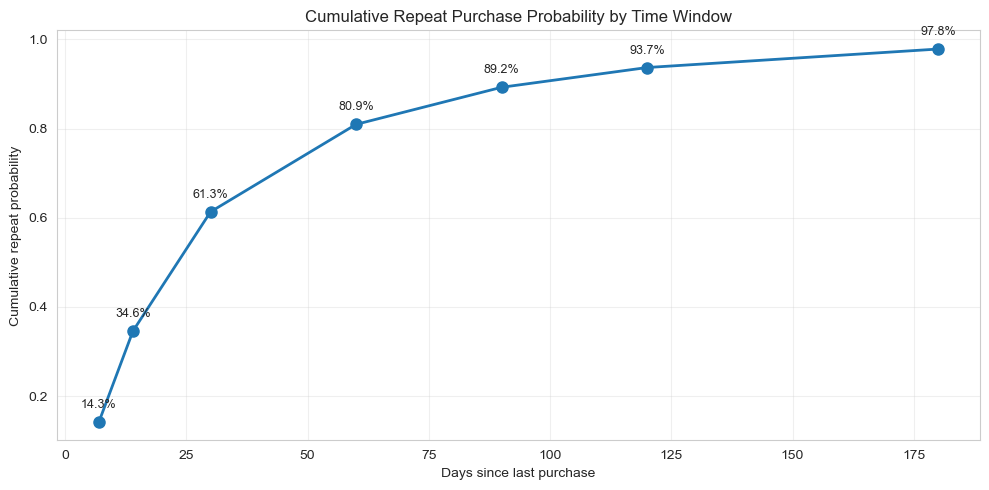

In [5]:
windows = [7, 14, 30, 60, 90, 120, 180]
total_gaps = len(gaps)

print("Repeat probability within time windows:")
print(f"{'Window':>10} {'Count':>10} {'Probability':>12} {'Cumulative':>12}")
print("-" * 46)

cumulative_probs = []
for w in windows:
    count = gaps.filter(pl.col("gap_days") <= w).height
    prob = count / total_gaps
    cumulative_probs.append((w, prob))
    print(f"{w:>7}d {count:>10,} {prob:>11.1%}")

# Plot cumulative repeat probability
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([w for w, _ in cumulative_probs], [p for _, p in cumulative_probs], 'o-', linewidth=2, markersize=8)
ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Cumulative repeat probability")
ax.set_title("Cumulative Repeat Purchase Probability by Time Window")
ax.grid(True, alpha=0.3)
for w, p in cumulative_probs:
    ax.annotate(f"{p:.1%}", (w, p), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Distribution of Interpurchase Gaps

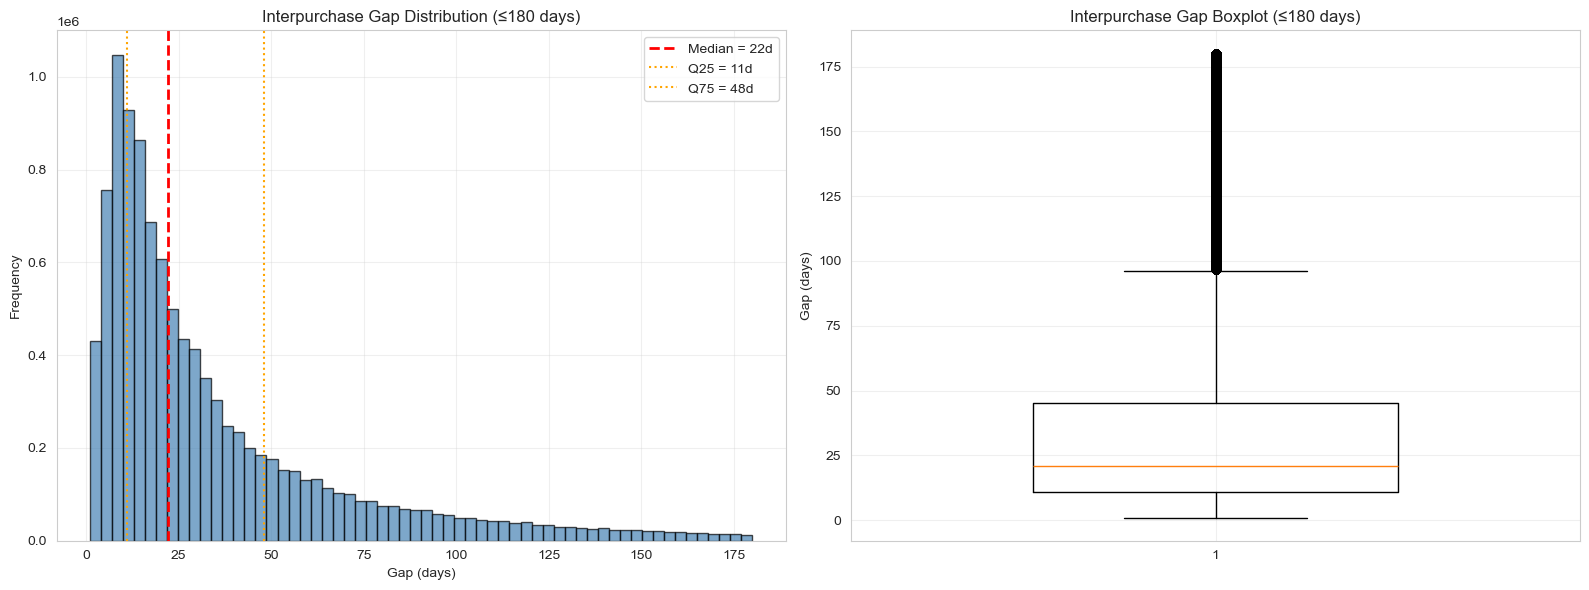

In [6]:
# Cap at 180 days for visualization
gap_data = gaps.filter(pl.col("gap_days") <= 180).select("gap_days").to_series().to_list()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(gap_data, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=median_gap, color='red', linestyle='--', linewidth=2, label=f'Median = {median_gap:.0f}d')
axes[0].axvline(x=q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q25 = {q25:.0f}d')
axes[0].axvline(x=q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q75 = {q75:.0f}d')
axes[0].set_xlabel('Gap (days)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Interpurchase Gap Distribution (≤180 days)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(gap_data, vert=True, widths=0.5)
axes[1].set_ylabel('Gap (days)')
axes[1].set_title('Interpurchase Gap Boxplot (≤180 days)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Top Repeat Items

In [7]:
item_repeat_stats = (
    gaps
    .group_by("item_id")
    .agg([
        pl.col("gap_days").median().alias("median_gap"),
        pl.col("gap_days").quantile(0.25).alias("q25_gap"),
        pl.col("gap_days").quantile(0.75).alias("q75_gap"),
        pl.col("gap_days").mean().alias("mean_gap"),
        pl.col("gap_days").count().alias("repeat_count"),
        pl.col("customer_id").n_unique().alias("unique_customers"),
    ])
    .with_columns(
        (pl.col("q75_gap") - pl.col("q25_gap")).alias("iqr_gap")
    )
    .sort("repeat_count", descending=True)
)

print("Top 20 Most Frequently Repurchased Items:")
print(item_repeat_stats.head(20).select(["item_id", "repeat_count", "unique_customers", "median_gap", "iqr_gap", "mean_gap"]))

Top 20 Most Frequently Repurchased Items:
shape: (20, 6)
┌───────────────┬──────────────┬──────────────────┬────────────┬─────────┬───────────┐
│ item_id       ┆ repeat_count ┆ unique_customers ┆ median_gap ┆ iqr_gap ┆ mean_gap  │
│ ---           ┆ ---          ┆ ---              ┆ ---        ┆ ---     ┆ ---       │
│ str           ┆ u32          ┆ u32              ┆ f64        ┆ f64     ┆ f64       │
╞═══════════════╪══════════════╪══════════════════╪════════════╪═════════╪═══════════╡
│ 4690000000001 ┆ 266505       ┆ 104770           ┆ 35.0       ┆ 53.0    ┆ 54.917262 │
│ 7176000000002 ┆ 141361       ┆ 37598            ┆ 18.0       ┆ 24.0    ┆ 28.289436 │
│ 3773000000004 ┆ 112527       ┆ 21633            ┆ 11.0       ┆ 10.0    ┆ 15.922819 │
│ 0020010000440 ┆ 96428        ┆ 15916            ┆ 14.0       ┆ 15.0    ┆ 20.633011 │
│ 7175000000002 ┆ 88882        ┆ 21521            ┆ 14.0       ┆ 21.0    ┆ 24.659864 │
│ …             ┆ …            ┆ …                ┆ …          ┆ …       

## 8. Category, Brand & Manufacturer Level Replenishment

In [8]:
# Join gaps with item metadata
items_df = items.collect()
gaps_with_meta = gaps.join(items_df, on="item_id", how="left")

def compute_group_stats(df, group_col):
    """Compute replenishment stats grouped by a column."""
    return (
        df
        .filter(pl.col(group_col).is_not_null())
        .group_by(group_col)
        .agg([
            pl.col("gap_days").median().alias("median_gap"),
            pl.col("gap_days").quantile(0.25).alias("q25_gap"),
            pl.col("gap_days").quantile(0.75).alias("q75_gap"),
            pl.col("gap_days").mean().alias("mean_gap"),
            pl.col("gap_days").count().alias("repeat_count"),
            pl.col("customer_id").n_unique().alias("unique_customers"),
            (pl.col("gap_days") <= 30).sum().alias("repeats_within_30d"),
        ])
        .with_columns([
            (pl.col("q75_gap") - pl.col("q25_gap")).alias("iqr_gap"),
            (pl.col("repeats_within_30d") / pl.col("repeat_count") * 100).alias("pct_within_30d"),
        ])
        .sort("repeat_count", descending=True)
    )

# Category-level stats
category_stats = compute_group_stats(gaps_with_meta, "category")
print("=== Category-Level Replenishment (Top 15) ===")
print(category_stats.head(15).select(["category", "repeat_count", "unique_customers", "median_gap", "iqr_gap", "pct_within_30d"]))

# Brand-level stats
brand_stats = compute_group_stats(gaps_with_meta, "brand")
print("\n=== Brand-Level Replenishment (Top 15) ===")
print(brand_stats.head(15).select(["brand", "repeat_count", "unique_customers", "median_gap", "iqr_gap", "pct_within_30d"]))

# Manufacturer-level stats
manufacturer_stats = compute_group_stats(gaps_with_meta, "manufacturer")
print("\n=== Manufacturer-Level Replenishment (Top 15) ===")
print(manufacturer_stats.head(15).select(["manufacturer", "repeat_count", "unique_customers", "median_gap", "iqr_gap", "pct_within_30d"]))

=== Category-Level Replenishment (Top 15) ===
shape: (15, 6)
┌────────────────────────┬──────────────┬──────────────────┬────────────┬─────────┬────────────────┐
│ category               ┆ repeat_count ┆ unique_customers ┆ median_gap ┆ iqr_gap ┆ pct_within_30d │
│ ---                    ┆ ---          ┆ ---              ┆ ---        ┆ ---     ┆ ---            │
│ str                    ┆ u32          ┆ u32              ┆ f64        ┆ f64     ┆ f64            │
╞════════════════════════╪══════════════╪══════════════════╪════════════╪═════════╪════════════════╡
│ Hoff                   ┆ 458646       ┆ 93378            ┆ 28.0       ┆ 41.0    ┆ 53.488965      │
│ Khăn ướt Animo         ┆ 283070       ┆ 109709           ┆ 35.0       ┆ 54.0    ┆ 43.775391      │
│ Sài Gòn Food           ┆ 256368       ┆ 34114            ┆ 18.0       ┆ 33.0    ┆ 67.663281      │
│ Takato_Tã Quần         ┆ 253621       ┆ 59588            ┆ 23.0       ┆ 24.0    ┆ 64.963075      │
│ Cây Thị                ┆ 232


=== Brand-Level Replenishment (Top 15) ===
shape: (15, 6)
┌────────────────────────┬──────────────┬──────────────────┬────────────┬─────────┬────────────────┐
│ brand                  ┆ repeat_count ┆ unique_customers ┆ median_gap ┆ iqr_gap ┆ pct_within_30d │
│ ---                    ┆ ---          ┆ ---              ┆ ---        ┆ ---     ┆ ---            │
│ str                    ┆ u32          ┆ u32              ┆ f64        ┆ f64     ┆ f64            │
╞════════════════════════╪══════════════╪══════════════════╪════════════╪═════════╪════════════════╡
│ Animo                  ┆ 587941       ┆ 203782           ┆ 41.0       ┆ 62.0    ┆ 38.530567      │
│ HOFF                   ┆ 458646       ┆ 93378            ┆ 28.0       ┆ 41.0    ┆ 53.488965      │
│ Takato                 ┆ 340134       ┆ 85312            ┆ 21.0       ┆ 23.0    ┆ 67.720663      │
│ Aptamil Newzealand     ┆ 289283       ┆ 50615            ┆ 12.0       ┆ 13.0    ┆ 85.551864      │
│ Sài Gòn Food           ┆ 25636


=== Manufacturer-Level Replenishment (Top 15) ===
shape: (15, 6)
┌────────────────────────┬──────────────┬──────────────────┬────────────┬─────────┬────────────────┐
│ manufacturer           ┆ repeat_count ┆ unique_customers ┆ median_gap ┆ iqr_gap ┆ pct_within_30d │
│ ---                    ┆ ---          ┆ ---              ┆ ---        ┆ ---     ┆ ---            │
│ str                    ┆ u32          ┆ u32              ┆ f64        ┆ f64     ┆ f64            │
╞════════════════════════╪══════════════╪══════════════════╪════════════╪═════════╪════════════════╡
│ Không xác định         ┆ 5874136      ┆ 763911           ┆ 26.0       ┆ 43.0    ┆ 55.798793      │
│ Công ty Cổ Phần Thực   ┆ 370823       ┆ 79811            ┆ 17.0       ┆ 23.0    ┆ 73.432069      │
│ Phẩm Dinh…             ┆              ┆                  ┆            ┆         ┆                │
│ Danone                 ┆ 289283       ┆ 50615            ┆ 12.0       ┆ 13.0    ┆ 85.551864      │
│ Công Ty Cổ Phần Sữa    

## 9. Empirical Survival (Replenishment) Curves

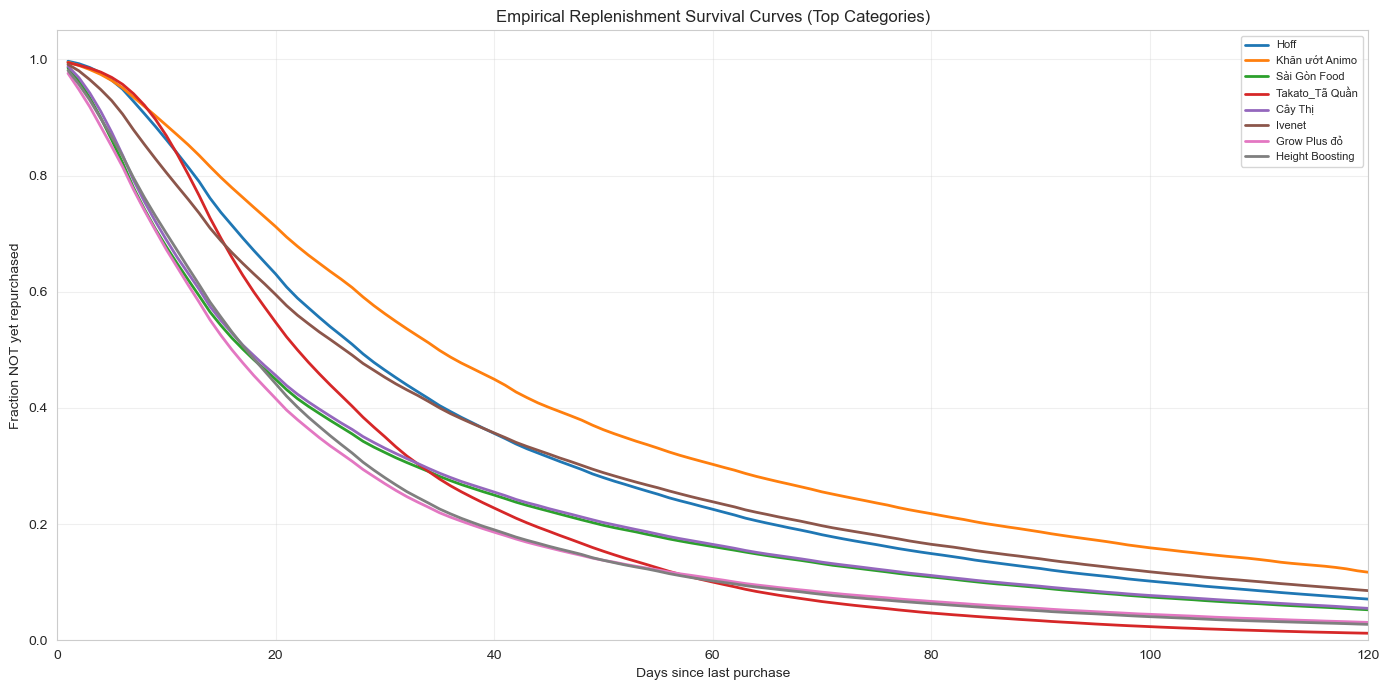

In [9]:
# Build survival curves for top categories
top_categories = category_stats.head(8).select("category").to_series().to_list()

fig, ax = plt.subplots(figsize=(14, 7))
max_days = 120
days_range = np.arange(1, max_days + 1)

for cat in top_categories:
    cat_gaps = (
        gaps_with_meta
        .filter(pl.col("category") == cat)
        .select("gap_days")
        .to_series()
        .to_numpy()
    )
    if len(cat_gaps) < 10:
        continue
    # Empirical survival: P(gap > t)
    survival = np.array([np.mean(cat_gaps > d) for d in days_range])
    label = cat if cat and len(cat) <= 30 else (cat[:27] + '...' if cat else 'Unknown')
    ax.plot(days_range, survival, linewidth=2, label=label)

ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Fraction NOT yet repurchased")
ax.set_title("Empirical Replenishment Survival Curves (Top Categories)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_days)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 10. Repeat-Rate by Category, Brand & Manufacturer

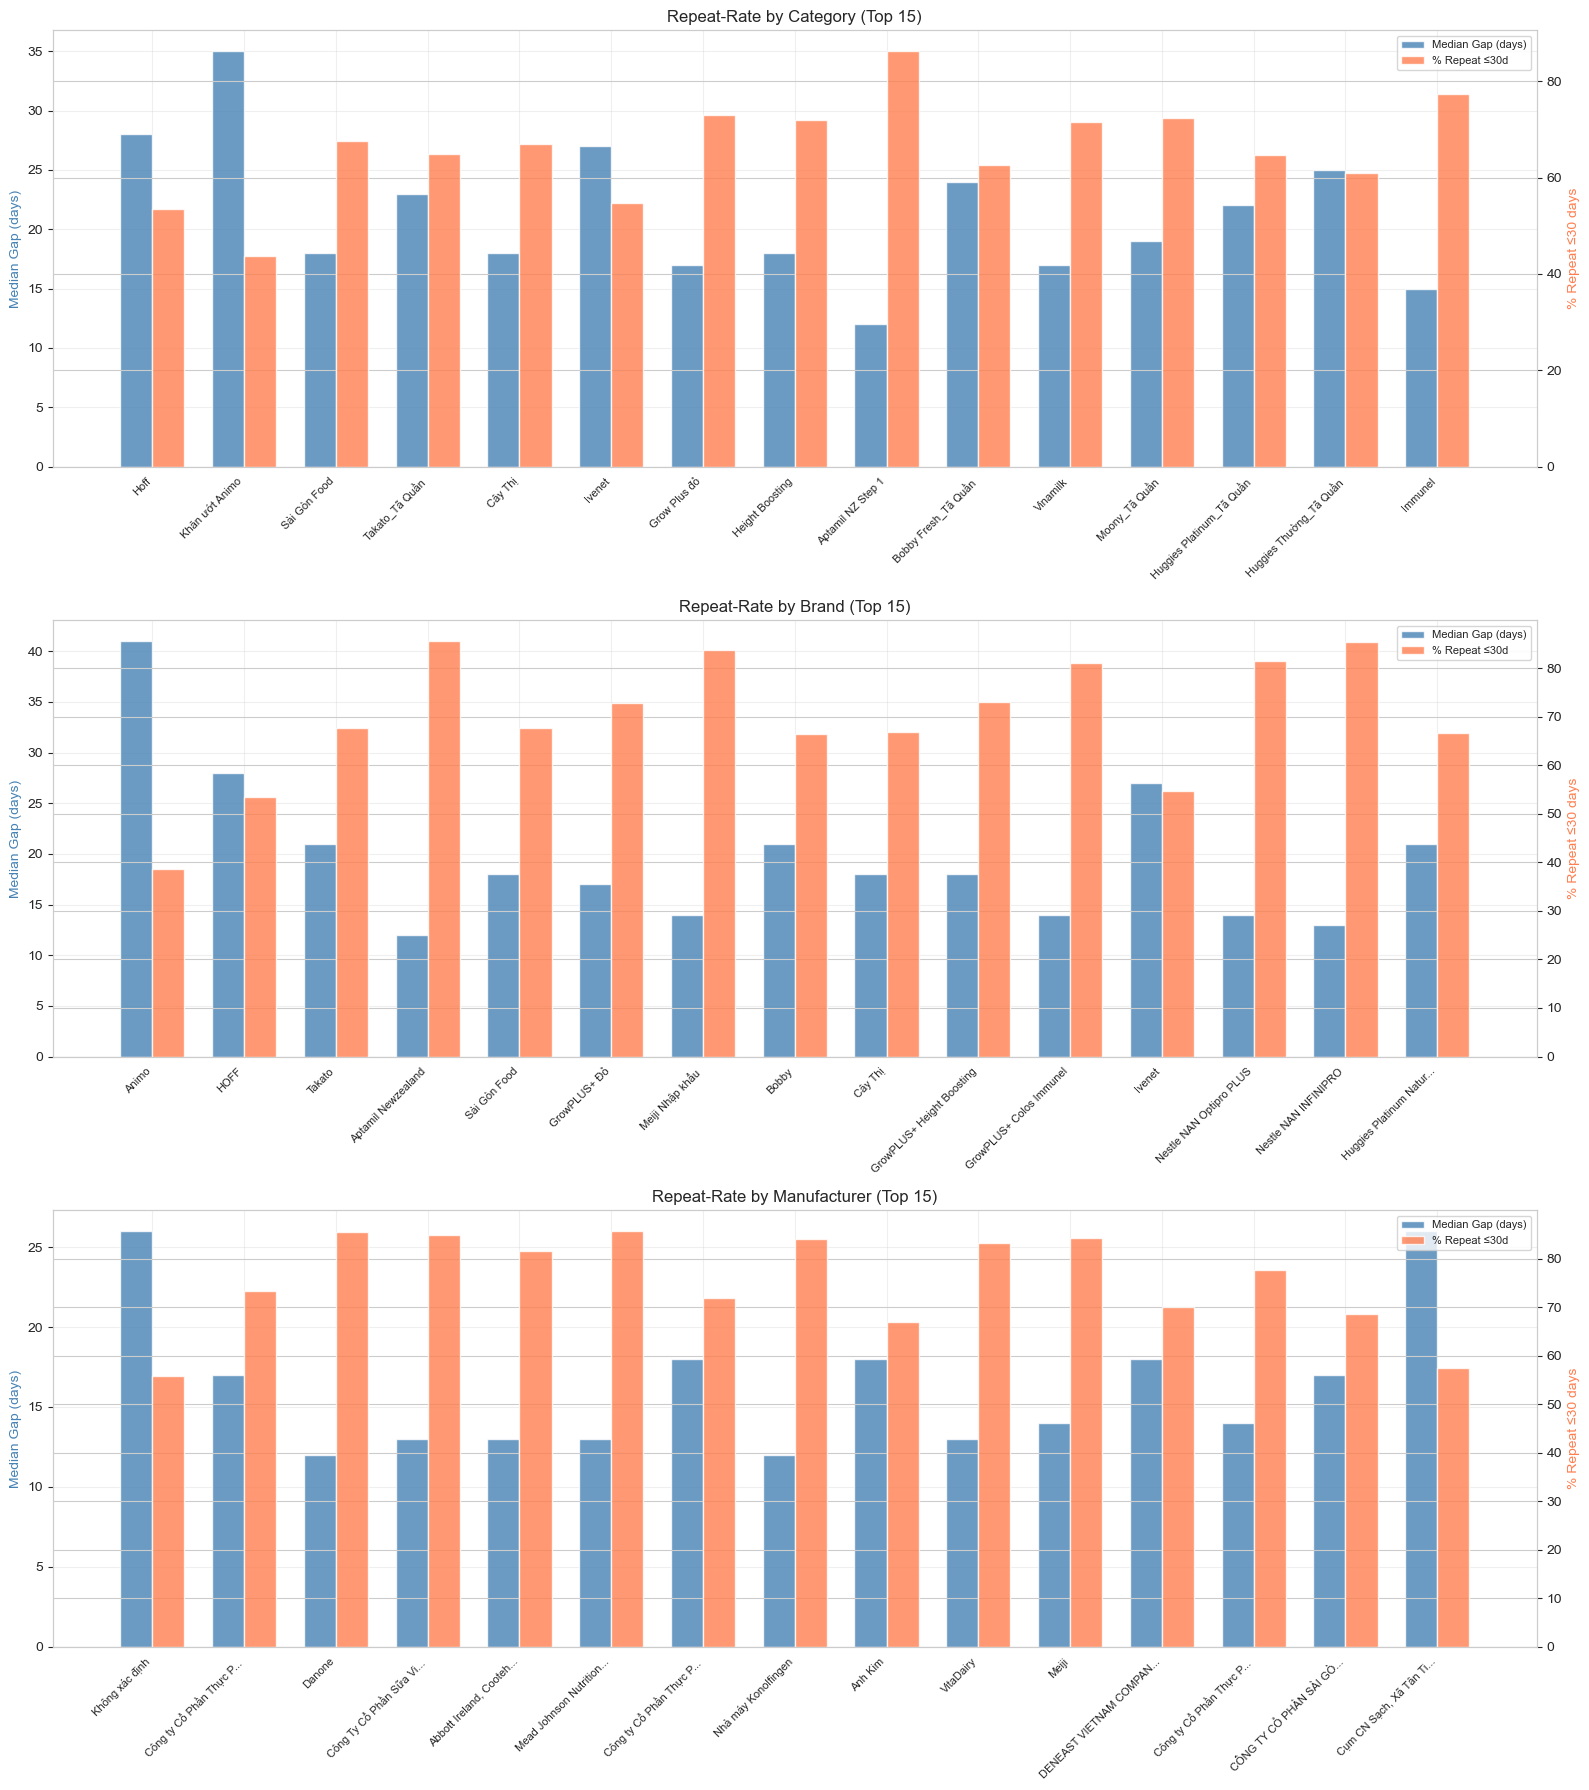

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

def plot_repeat_rate(ax, stats_df, group_col, title, top_n=15):
    top = stats_df.head(top_n)
    labels = top.select(group_col).to_series().to_list()
    labels = [l if l and len(l) <= 25 else ((l[:22] + '...') if l else 'Unknown') for l in labels]
    medians = top.select("median_gap").to_series().to_list()
    pct_30d = top.select("pct_within_30d").to_series().to_list()
    
    x = np.arange(len(labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, medians, width, label='Median Gap (days)', color='steelblue', alpha=0.8)
    ax2 = ax.twinx()
    bars2 = ax2.bar(x + width/2, pct_30d, width, label='% Repeat ≤30d', color='coral', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Median Gap (days)', color='steelblue')
    ax2.set_ylabel('% Repeat ≤30 days', color='coral')
    ax.set_title(title)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plot_repeat_rate(axes[0], category_stats, "category", "Repeat-Rate by Category (Top 15)")
plot_repeat_rate(axes[1], brand_stats, "brand", "Repeat-Rate by Brand (Top 15)")
plot_repeat_rate(axes[2], manufacturer_stats, "manufacturer", "Repeat-Rate by Manufacturer (Top 15)")

plt.tight_layout()
plt.show()

## 11. Conclusion and Decision

**Decision Rule:** Keep the idea if the repeat cycle is sharp enough to support replenishment reminders or next-buy predictions.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Total customer-item pairs | **26,163,063** |
| Pairs with repeat purchases | **4,485,202 (17.1%)** |
| Total gap observations | **10,869,249** |
| Median interpurchase gap | **22.0 days** |
| IQR of gaps | **[11, 48] = 37 days** |
| Mean interpurchase gap | **38.7 days** |
| Repeat probability ≤7 days | **14.3%** |
| Repeat probability ≤14 days | **34.6%** |
| Repeat probability ≤30 days | **61.3%** |
| Repeat probability ≤60 days | **80.9%** |
| Repeat probability ≤90 days | **89.2%** |

### Interpretation

1. **The repeat-purchase signal is strong and actionable.** 17.1% of all customer-item pairs involve repeat purchases, yielding over 10.8 million gap observations — a very large statistical base. The median gap of **22 days** and a concentration of 61.3% of repeats within 30 days indicate a clear, short replenishment cycle.

2. **The cycle is moderately sharp but varies by category.** The overall IQR of 37 days is relatively wide, but when analyzed at the category/brand level, some segments show much tighter cycles:
   - **Aptamil Newzealand / Danone**: median gap 12 days, IQR 13 days, 85.6% repeat ≤30d — very tight, predictable cycle (infant formula)
   - **Nestle NAN INFINIPRO**: median gap 13 days, IQR 14 days, 85.4% repeat ≤30d
   - **Vinamilk**: median gap 17 days, IQR 24 days, 71.5% repeat ≤30d (dairy products)
   - **Immunel / GrowPLUS+**: median gap 14–15 days, IQR 17–21 days, 77–81% repeat ≤30d
   - **Takato (diapers)**: median gap 21–23 days, IQR 23–24 days, 65–68% repeat ≤30d
   - **Huggies (diapers)**: median gap 21–25 days, IQR 24–28 days, 61–67% repeat ≤30d

3. **Category-level analysis reveals two clear replenishment tiers:**
   - **Tier 1 (Fast cycle, ≤15 day median):** Infant formula brands (Aptamil, NAN, GrowPLUS+, Immunel, Meiji) — these show the tightest, most predictable cycles with >77% repeat within 30 days.
   - **Tier 2 (Medium cycle, 18–30 day median):** Diapers (Takato, Huggies, Moony), food products (Sài Gòn Food, Cây Thị, Hoff), and wet wipes (Animo) — predictable but with slightly wider variance.

4. **The survival curves confirm steep replenishment drop-offs.** For Tier 1 categories, the fraction of customers who have NOT repurchased drops below 20% by day 30, indicating highly predictable demand. Tier 2 categories show a more gradual curve but still reach <40% by day 30.

5. **Manufacturer-level analysis is partially obscured by data quality.** The top manufacturer slot is "Không xác định" (Unknown) with 5.87M repeats, indicating significant data quality gaps in the manufacturer field. Despite this, known manufacturers like Danone (12d median), Vinamilk (13d), Abbott (13d), and Meiji (14d) show very consistent short cycles.

### Decision

**KEEP — strong replenishment signal for consumable categories.**

The data provides robust evidence that replenishment cycles are predictable, especially for:
- **Infant formula:** 12–15 day cycles with >80% repeat within 30 days → ideal for automated replenishment reminders.
- **Diapers:** 21–25 day cycles with >60% repeat within 30 days → suitable for proactive restocking notifications.
- **Food/snacks and wet wipes:** 18–35 day cycles → useful for next-buy prediction models.

**Recommended next steps:**
- Build per-category replenishment timers based on median gap + IQR for personalized reminders.
- Combine with Idea 5 (seasonality) to adjust replenishment timing for weekday/monthly effects.
- Prioritize Tier 1 categories (infant formula) for MVP replenishment features due to the strongest signal.
- Address manufacturer data quality to unlock manufacturer-level insights.